# Study 2 — Irrational Commitment & Correction Analysis

**Commitment criterion:** P(irrational) > P(mode) at D1 — the model's preferred output has shifted to the irrational choice.

## Distribution Shift: Distance from D0 Mode

D0 = baseline, D1 = after irrational memory injection, D2 = after correction cue.

X-axis = distance from D0 mode position. Positive direction = toward irrational choice.

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})

# ── Load data ──
with open("deepseek_study1_baseline_results.jsonl") as f:
    baselines = [json.loads(line) for line in f if line.strip()]

with open("/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/outputs/deepseek_study2_testing_results.jsonl") as f:
    exp_rows = [json.loads(line) for line in f if line.strip()]

# Baseline lookup: qid -> {probs, mode}
bl_lookup = {}
for b in baselines:
    qid = b["metadata"]["qid"]
    probs = {int(k): v for k, v in b["response"]["probs"].items()}
    mode = int(b["response"]["answer"])
    bl_lookup[qid] = {"probs": probs, "mode": mode}

# Trial lookup: (qid, irr_choice) -> {condition: row}
trials = defaultdict(dict)
for r in exp_rows:
    m = r["metadata"]
    key = (m["qid"], m["irrational_choice"])
    trials[key][m["condition"]] = r

print(f"Baselines: {len(bl_lookup)} dilemmas")
print(f"Trials: {len(trials)} (qid, irr_choice) pairs")

Baselines: 78 dilemmas
Trials: 424 (qid, irr_choice) pairs


In [4]:
records = []
for (qid, irr), conds in trials.items():
    d1_row = conds.get("memory_justify")
    d2_row = conds.get("memory_justify_correction")
    bl = bl_lookup.get(qid)
    if not d1_row or not d2_row or not bl:
        continue

    mode = bl["mode"]
    p_irr_d0 = bl["probs"].get(irr, 0)
    p_irr_d1 = d1_row["response"]["probs"].get(str(irr), 0)
    p_irr_d2 = d2_row["response"]["probs"].get(str(irr), 0)
    p_mode_d1 = d1_row["response"]["probs"].get(str(mode), 0)

    delta_commit = p_irr_d1 - p_irr_d0

    # Full distribution arrays (positions 1-7)
    dist_d0 = np.array([bl["probs"].get(i, 0) for i in range(1, 8)])
    dist_d1 = np.array([d1_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])
    dist_d2 = np.array([d2_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])

    records.append({
        "qid": qid, "irr": irr, "mode": mode,
        "p_irr_d0": p_irr_d0, "p_irr_d1": p_irr_d1, "p_irr_d2": p_irr_d2,
        "p_mode_d1": p_mode_d1,
        "delta_commit": delta_commit,
        "delta_correction": p_irr_d2 - p_irr_d1,
        "net_residual": p_irr_d2 - p_irr_d0,
        "committed": p_irr_d1 > p_mode_d1,
        "dist_d0": dist_d0, "dist_d1": dist_d1, "dist_d2": dist_d2,
    })

all_trials = records
committed = [r for r in records if r["committed"]]

print(f"Total trials: {len(all_trials)}")
print(f"Committed (P(irr) > P(mode) at D1): {len(committed)} ({len(committed)/len(all_trials)*100:.1f}%)")
print(f"Not committed: {len(all_trials) - len(committed)}")

Total trials: 424
Committed (P(irr) > P(mode) at D1): 335 (79.0%)
Not committed: 89


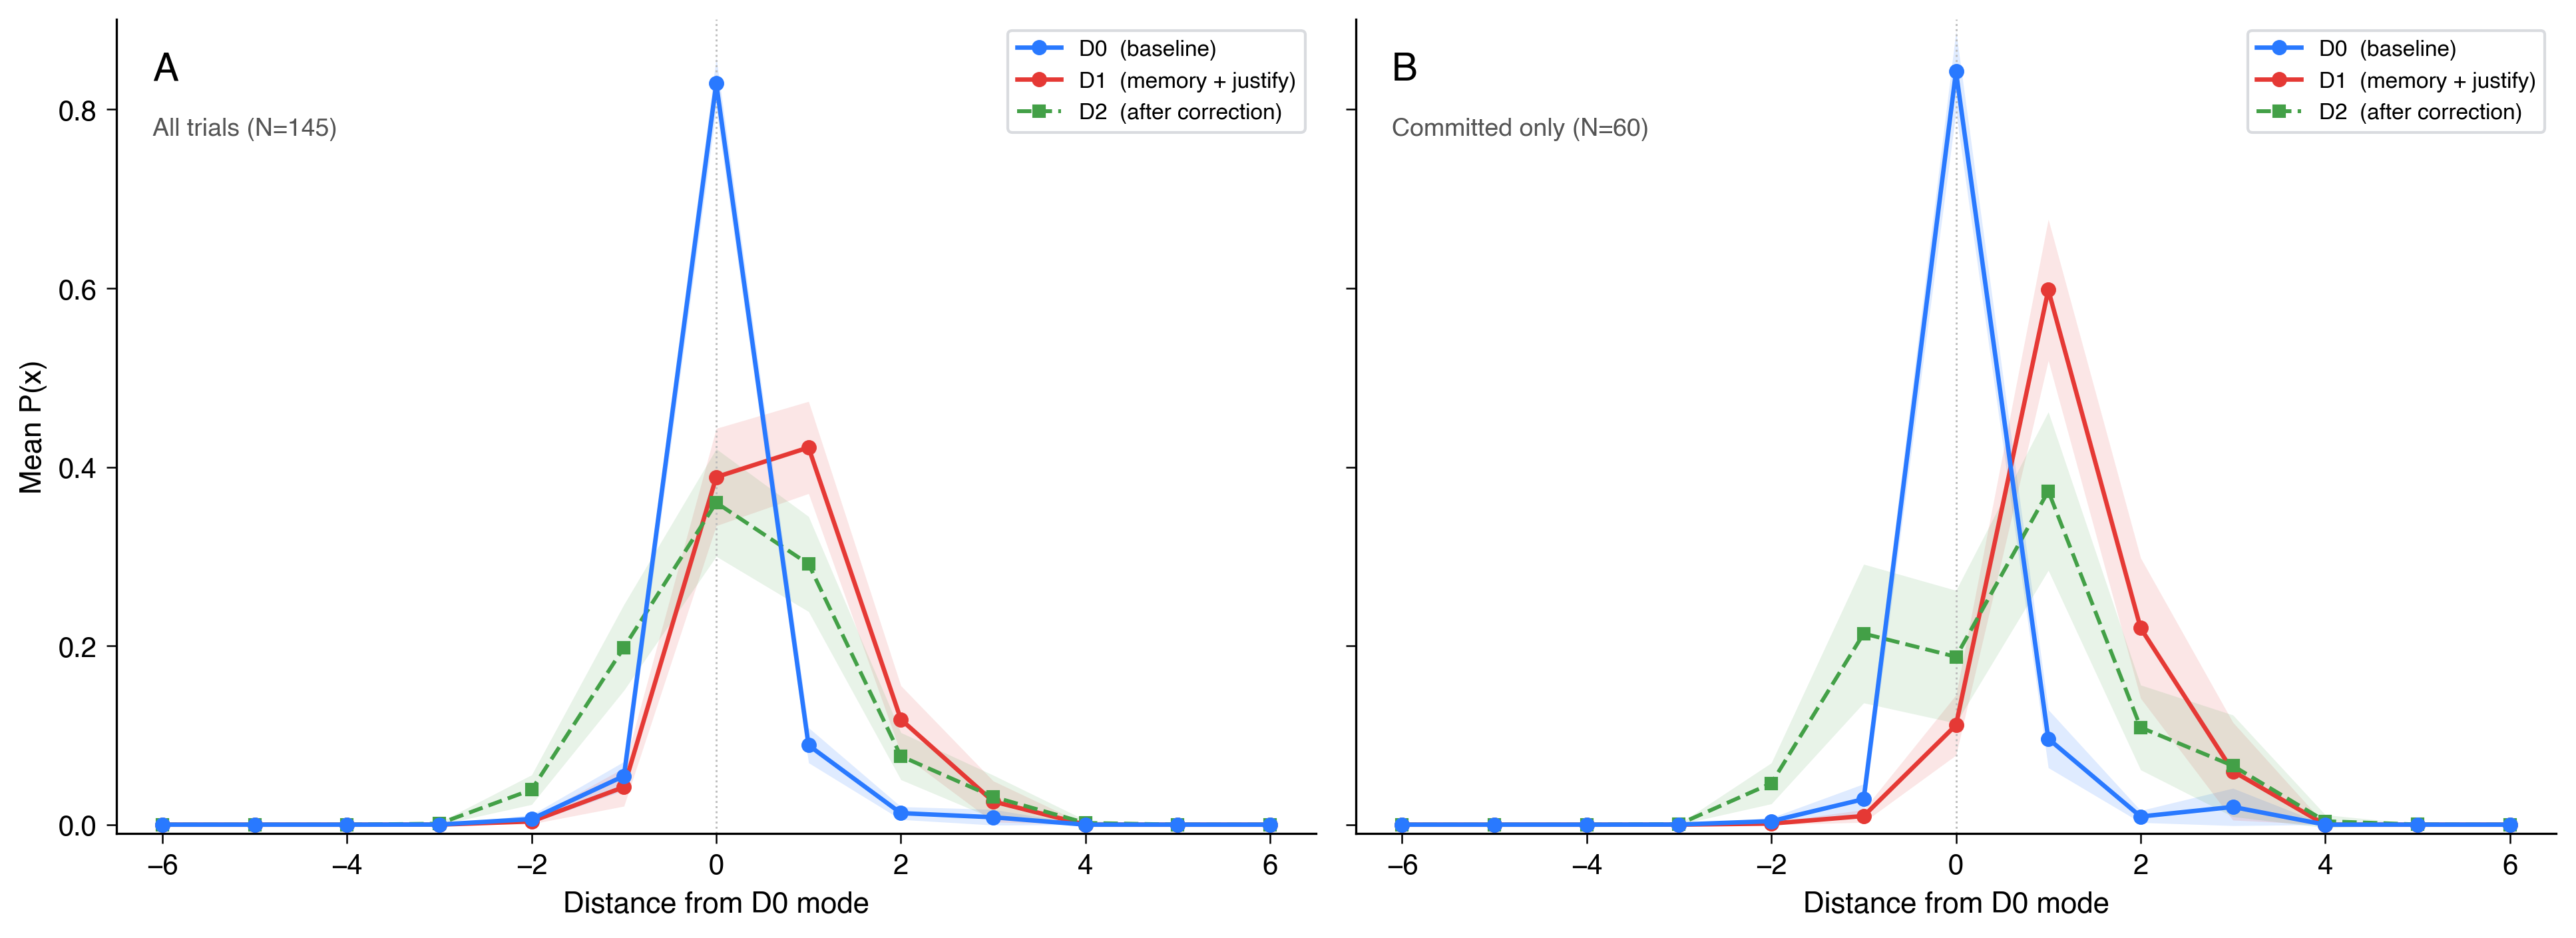

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 300,
    "figure.facecolor": "white",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

# ── Load data ──
baseline_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/baseline_outputs_explicit_format.jsonl"
exp_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study2/study2_v3_experimental_outputs.jsonl"

with open(baseline_path, "r", encoding="utf-8") as f:
    baselines = [json.loads(line) for line in f if line.strip()]
with open(exp_path, "r", encoding="utf-8") as f:
    exp_rows = [json.loads(line) for line in f if line.strip()]

bl_lookup = {}
for b in baselines:
    qid = b["metadata"]["qid"]
    probs = {int(k): v for k, v in b["response"]["probs"].items()}
    mode = int(b["response"]["answer"])
    bl_lookup[qid] = {"probs": probs, "mode": mode}

trials = defaultdict(dict)
for r in exp_rows:
    m = r["metadata"]
    key = (m["qid"], m["irrational_choice"])
    trials[key][m["condition"]] = r

# ── Build records ──
records = []
for (qid, irr), conds in trials.items():
    d1_row = conds.get("memory_justify")
    d2_row = conds.get("memory_justify_correction")
    bl = bl_lookup.get(qid)
    if not d1_row or not d2_row or not bl:
        continue
    mode = bl["mode"]
    p_irr_d1 = d1_row["response"]["probs"].get(str(irr), 0)
    p_mode_d1 = d1_row["response"]["probs"].get(str(mode), 0)

    dist_d0 = np.array([bl["probs"].get(i, 0) for i in range(1, 8)])
    dist_d1 = np.array([d1_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])
    dist_d2 = np.array([d2_row["response"]["probs"].get(str(i), 0) for i in range(1, 8)])

    records.append({
        "irr": irr, "mode": mode,
        "committed": p_irr_d1 > p_mode_d1,
        "dist_d0": dist_d0, "dist_d1": dist_d1, "dist_d2": dist_d2,
    })

all_trials = records
committed = [r for r in records if r["committed"]]


# ── Helpers ──
def reindex_dist(dist_array, mode, irr):
    sign = 1 if irr >= mode else -1
    result = {}
    for pos_idx, prob in enumerate(dist_array):
        pos = pos_idx + 1
        d = (pos - mode) * sign
        result[d] = result.get(d, 0) + prob
    return result


def aggregate_dists(records, key):
    """Return mean and 95% CI half-width at each distance."""
    dist_accum = defaultdict(list)
    for r in records:
        reindexed = reindex_dist(r[key], r["mode"], r["irr"])
        for d in range(-6, 7):
            dist_accum[d].append(reindexed.get(d, 0))
    mean_dist = {}
    ci95_dist = {}
    for d, vals in dist_accum.items():
        vals = np.array(vals)
        n = len(vals)
        mean_dist[d] = np.mean(vals)
        # 95% CI = 1.96 * SE
        ci95_dist[d] = 1.96 * np.std(vals, ddof=1) / np.sqrt(n)
    return mean_dist, ci95_dist


# ── Colors ──
C_D0 = "#2979FF"   # blue
C_D1 = "#E53935"   # red
C_D2 = "#43A047"   # green


def plot_panel(ax, recs, panel_label, n_label):
    """Plot D0/D1/D2 on one axis with 95% CI bands."""
    x = np.arange(-6, 7)

    mean_d0, ci_d0 = aggregate_dists(recs, "dist_d0")
    mean_d1, ci_d1 = aggregate_dists(recs, "dist_d1")
    mean_d2, ci_d2 = aggregate_dists(recs, "dist_d2")

    y0 = np.array([mean_d0.get(d, 0) for d in x])
    y1 = np.array([mean_d1.get(d, 0) for d in x])
    y2 = np.array([mean_d2.get(d, 0) for d in x])
    c0 = np.array([ci_d0.get(d, 0) for d in x])
    c1 = np.array([ci_d1.get(d, 0) for d in x])
    c2 = np.array([ci_d2.get(d, 0) for d in x])

    # 95% CI bands
    ax.fill_between(x, y0 - c0, y0 + c0, alpha=0.15, color=C_D0, linewidth=0)
    ax.fill_between(x, y1 - c1, y1 + c1, alpha=0.12, color=C_D1, linewidth=0)
    ax.fill_between(x, y2 - c2, y2 + c2, alpha=0.12, color=C_D2, linewidth=0)

    # Lines
    ax.plot(x, y0, "o-", color=C_D0, markersize=4.5, linewidth=1.6,
            label="D0  (baseline)", zorder=4)
    ax.plot(x, y1, "o-", color=C_D1, markersize=4.5, linewidth=1.6,
            label="D1  (memory + justify)", zorder=3)
    ax.plot(x, y2, "s--", color=C_D2, markersize=4, linewidth=1.4,
            label="D2  (after correction)", zorder=3)

    # Mode reference line
    ax.axvline(0, color="#BDBDBD", linestyle=":", linewidth=0.7, zorder=1)

    # Panel label (A / B) in upper left
    ax.text(0.03, 0.96, panel_label, transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")

    # N label below panel label
    ax.text(0.03, 0.88, n_label, transform=ax.transAxes,
            fontsize=9, va="top", ha="left", color="#555555")

    # Axis labels
    ax.set_xlabel("Distance from D0 mode", fontsize=10.5)
    ax.set_ylabel("Mean P(x)", fontsize=10.5)
    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(bottom=-0.01)

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Legend
    ax.legend(fontsize=8, loc="upper right", frameon=True, fancybox=True,
              framealpha=0.9, edgecolor="#D5D8DC", borderpad=0.4)


# ── Figure ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

plot_panel(ax1, all_trials,  "A", f"All trials (N={len(all_trials)})")
plot_panel(ax2, committed,   "B", f"Committed only (N={len(committed)})")

# Remove duplicate y-label on right panel
ax2.set_ylabel("")

# ── 95% CI annotation on left panel ──
# Point to the CI band near the peak of D1
mean_d1_all, ci_d1_all = aggregate_dists(all_trials, "dist_d1")
peak_d = 1  # distance=1 is where D1 typically peaks for committed shift
peak_y = mean_d1_all.get(peak_d, 0)
peak_ci = ci_d1_all.get(peak_d, 0)

plt.tight_layout()
plt.savefig("distribution_shift_d0_d1_d2.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()


Total: 145
Committed: 60 (41.4%)
Not committed: 85
Persists: 32 (53.3% of committed)
Corrected: 28


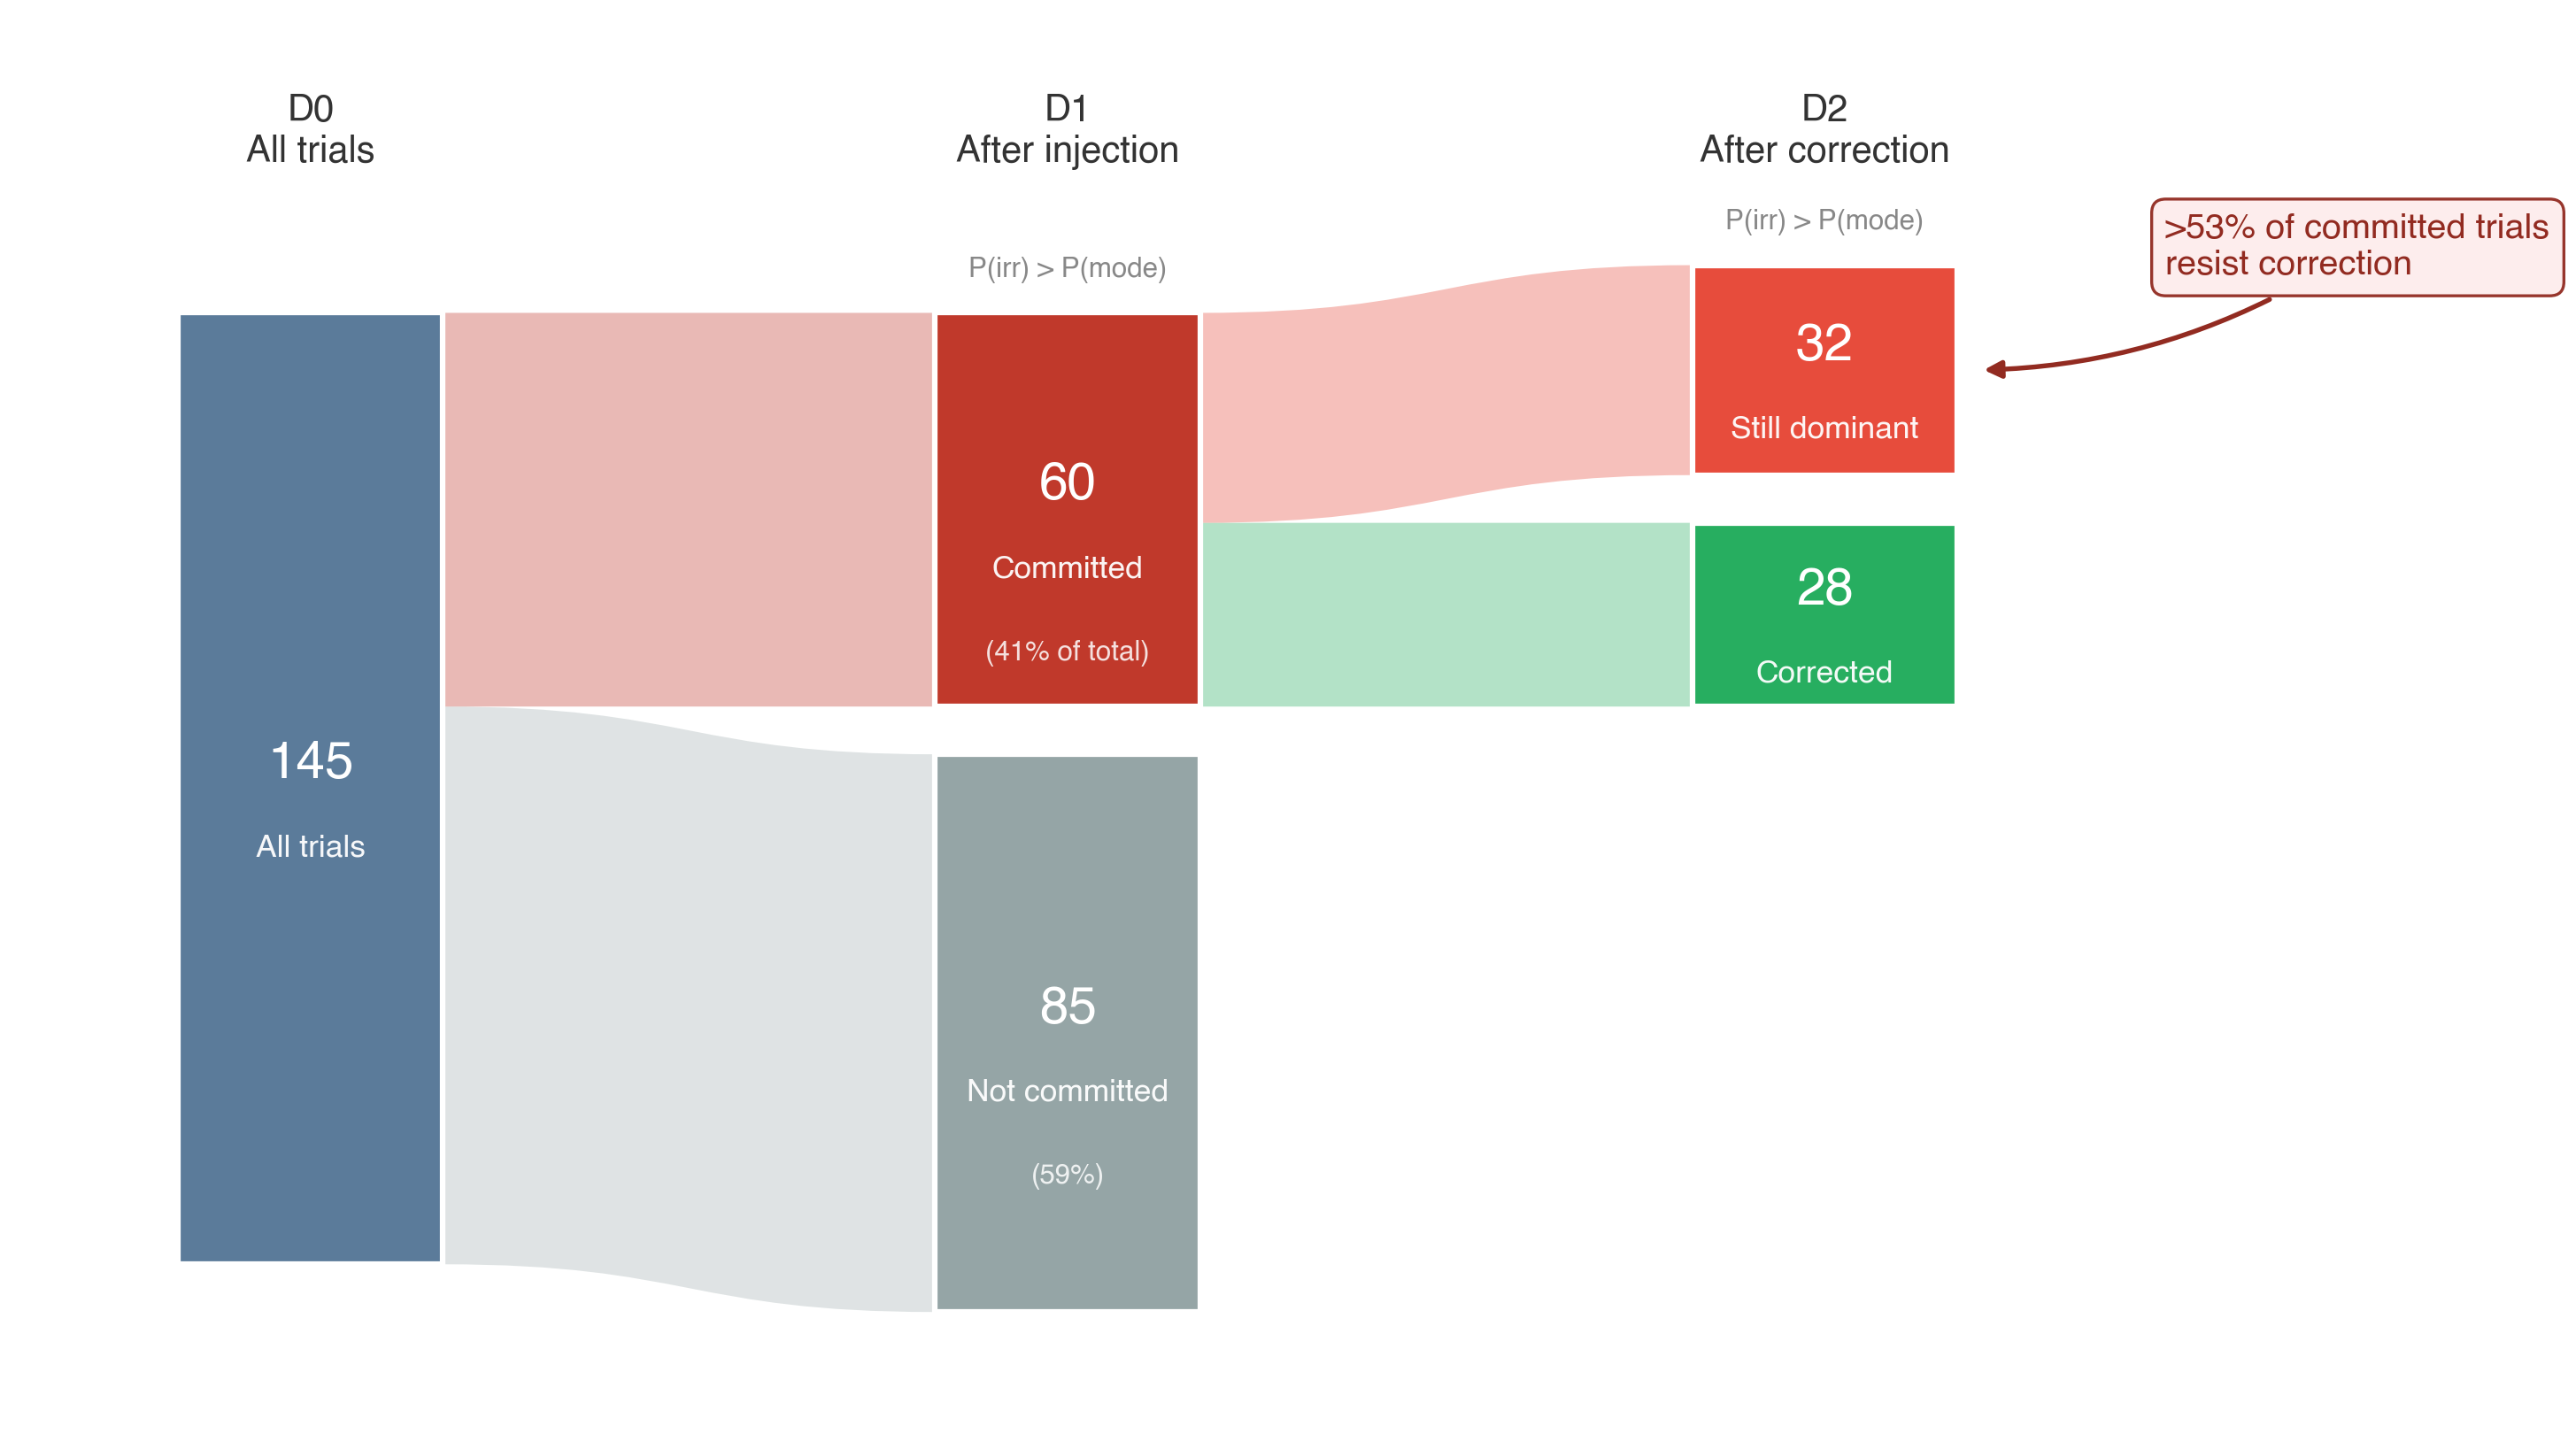


Total trials:         145
Committed at D1:      60 (41.4%)
Not committed:        85 (58.6%)
Still dominant at D2: 32 (53.3% of committed)
Corrected at D2:      28 (46.7% of committed)


In [65]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from collections import defaultdict

# ── Publication-quality settings ──
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "figure.dpi": 300,
    "figure.facecolor": "white",
})

# ── Load data ──
baseline_path = "/Users/wangbaihui/modeling_distributions_thesis/src/exp1_v2/outputs/exp1/study1/baseline_outputs_explicit_format.jsonl"
exp_path = "study2_v3_experimental_outputs.jsonl"

with open(baseline_path, "r", encoding="utf-8") as f:
    baselines = [json.loads(line) for line in f if line.strip()]
with open(exp_path, "r", encoding="utf-8") as f:
    exp_rows = [json.loads(line) for line in f if line.strip()]

bl_lookup = {}
for b in baselines:
    qid = str(b["metadata"]["qid"])
    mode = int(b["response"]["answer"])
    bl_lookup[qid] = {"mode": mode}

trials = defaultdict(dict)
for r in exp_rows:
    m = r["metadata"]
    key = (str(m["qid"]), int(m["irrational_choice"]))
    trials[key][m["condition"]] = r

# ── Classify ──
total = 0
n_committed = 0
n_persists = 0

for (qid, irr), conds in trials.items():
    d1 = conds.get("memory_justify")
    d2 = conds.get("memory_justify_correction")
    bl = bl_lookup.get(qid)
    if not d1 or not d2 or not bl:
        continue
    total += 1
    mode = bl["mode"]
    p_irr_d1 = float(d1["response"]["probs"].get(str(irr), 0))
    p_mode_d1 = float(d1["response"]["probs"].get(str(mode), 0))
    p_irr_d2 = float(d2["response"]["probs"].get(str(irr), 0))
    p_mode_d2 = float(d2["response"]["probs"].get(str(mode), 0))
    committed = p_irr_d1 > p_mode_d1
    persists = committed and (p_irr_d2 > p_mode_d2)
    if committed:
        n_committed += 1
    if persists:
        n_persists += 1

n_not_committed = total - n_committed
n_corrected = n_committed - n_persists
pct_committed = n_committed / total * 100
pct_persist = n_persists / n_committed * 100

print(f"Total: {total}")
print(f"Committed: {n_committed} ({pct_committed:.1f}%)")
print(f"Not committed: {n_not_committed}")
print(f"Persists: {n_persists} ({pct_persist:.1f}% of committed)")
print(f"Corrected: {n_corrected}")


# ═══════════════════════════════════════════════════════
# SANKEY-STYLE FLOW DIAGRAM (pure matplotlib)
# ═══════════════════════════════════════════════════════
from matplotlib.path import Path
import matplotlib.patches as mpatches_path


def draw_flow(ax, x0, y0_start, y0_end, x1, y1_start, y1_end, color, alpha=0.45):
    """Draw a smooth Sankey-style flow band between two vertical segments."""
    # Control points for the bezier curves
    xmid = (x0 + x1) / 2

    # Top edge path (y0_end -> y1_end)
    verts_top = [
        (x0, y0_end),
        (xmid, y0_end),
        (xmid, y1_end),
        (x1, y1_end),
    ]
    # Bottom edge path (y1_start -> y0_start), reversed
    verts_bot = [
        (x1, y1_start),
        (xmid, y1_start),
        (xmid, y0_start),
        (x0, y0_start),
    ]

    # Combine into a closed polygon with bezier curves
    verts = verts_top + verts_bot + [(x0, y0_end)]
    codes = [
        Path.MOVETO,
        Path.CURVE4, Path.CURVE4, Path.CURVE4,  # top edge
        Path.LINETO,                              # right side down
        Path.CURVE4, Path.CURVE4, Path.CURVE4,  # bottom edge
        Path.CLOSEPOLY,
    ]

    path = Path(verts, codes)
    patch = mpatches_path.PathPatch(path, facecolor=color, edgecolor="none",
                                     alpha=alpha, zorder=2)
    ax.add_patch(patch)


def draw_node(ax, x, y_bot, y_top, width, color, label, count, pct_text=None):
    """Draw a node rectangle with label."""
    rect = plt.Rectangle((x - width/2, y_bot), width, y_top - y_bot,
                          facecolor=color, edgecolor="white", linewidth=1.5, zorder=3)
    ax.add_patch(rect)

    # Label text
    mid_y = (y_bot + y_top) / 2
    height = y_top - y_bot

    # Main count
    ax.text(x, mid_y + 2, f"{count}",
            ha="center", va="center", fontsize=14, fontweight="bold",
            color="white", zorder=4)
    # Label below count
    if height > 15:
        ax.text(x, mid_y - 5, label,
                ha="center", va="center", fontsize=8.5,
                color="white", alpha=0.95, zorder=4)
    if pct_text and height > 20:
        ax.text(x, mid_y - 12, pct_text,
                ha="center", va="center", fontsize=7.5,
                color="white", alpha=0.85, zorder=4)


# ── Layout parameters ──
fig, ax = plt.subplots(figsize=(10, 5.5))

# X positions for three columns
x_col = [0, 4, 8]
node_w = 1.4  # node width

# Scale: 1 trial = 0.6 units of height
scale = 0.55
gap = 4  # vertical gap between stacked nodes in a column

# ── Column 0: All trials ──
h_total = total * scale
y0_total_bot = 0
y0_total_top = h_total

# ── Column 1: Committed + Not committed ──
h_committed = n_committed * scale
h_not = n_not_committed * scale

# Stack: not-committed on bottom, committed on top
y1_not_bot = 0
y1_not_top = h_not
y1_comm_bot = h_not + gap
y1_comm_top = y1_comm_bot + h_committed

# ── Column 2: Persists + Corrected (only from committed) ──
h_persist = n_persists * scale
h_corrected = n_corrected * scale

# Align with committed block vertically
y2_corr_bot = y1_comm_bot
y2_corr_top = y2_corr_bot + h_corrected
y2_pers_bot = y2_corr_top + gap
y2_pers_top = y2_pers_bot + h_persist

# Center the whole thing vertically
total_height = max(y0_total_top, y1_comm_top, y2_pers_top)
y_offset = (total_height - h_total) / 2
y0_total_bot += y_offset
y0_total_top += y_offset

# ── Colors ──
C_TOTAL = "#5B7B9A"       # steel blue
C_COMMITTED = "#C0392B"   # strong red
C_NOT_COMM = "#95A5A6"    # gray
C_PERSIST = "#E74C3C"     # lighter red
C_CORRECTED = "#27AE60"   # green

# ── Draw flows ──
# Total -> Not committed (bottom portion of total -> not committed node)
flow_not_top_in_total = y0_total_bot + n_not_committed * scale
draw_flow(ax, x_col[0] + node_w/2, y0_total_bot, flow_not_top_in_total,
          x_col[1] - node_w/2, y1_not_bot, y1_not_top,
          color=C_NOT_COMM, alpha=0.3)

# Total -> Committed (top portion of total -> committed node)
draw_flow(ax, x_col[0] + node_w/2, flow_not_top_in_total, y0_total_top,
          x_col[1] - node_w/2, y1_comm_bot, y1_comm_top,
          color=C_COMMITTED, alpha=0.35)

# Committed -> Corrected
flow_corr_top_in_comm = y1_comm_bot + n_corrected * scale
draw_flow(ax, x_col[1] + node_w/2, y1_comm_bot, flow_corr_top_in_comm,
          x_col[2] - node_w/2, y2_corr_bot, y2_corr_top,
          color=C_CORRECTED, alpha=0.35)

# Committed -> Persists
draw_flow(ax, x_col[1] + node_w/2, flow_corr_top_in_comm, y1_comm_top,
          x_col[2] - node_w/2, y2_pers_bot, y2_pers_top,
          color=C_PERSIST, alpha=0.35)

# ── Draw nodes ──
draw_node(ax, x_col[0], y0_total_bot, y0_total_top, node_w,
          C_TOTAL, "All trials", total)

draw_node(ax, x_col[1], y1_not_bot, y1_not_top, node_w,
          C_NOT_COMM, "Not committed", n_not_committed,
          f"({100-pct_committed:.0f}%)")

draw_node(ax, x_col[1], y1_comm_bot, y1_comm_top, node_w,
          C_COMMITTED, "Committed", n_committed,
          f"({pct_committed:.0f}% of total)")

draw_node(ax, x_col[2], y2_corr_bot, y2_corr_top, node_w,
          C_CORRECTED, "Corrected", n_corrected,
          f"({100-pct_persist:.0f}% of committed)")

draw_node(ax, x_col[2], y2_pers_bot, y2_pers_top, node_w,
          C_PERSIST, "Still dominant", n_persists,
          f"({pct_persist:.0f}% of committed)")

# ── Column headers ──
header_y = total_height + 8
ax.text(x_col[0], header_y, "D0\nAll trials",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333")
ax.text(x_col[1], header_y, "D1\nAfter injection",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333")
ax.text(x_col[2], header_y, "D2\nAfter correction",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#333333")

# ── Criterion labels ──
ax.text(x_col[1], y1_comm_top + 2.5,
        "P(irr) > P(mode)",
        ha="center", va="bottom", fontsize=7.5, fontstyle="italic", color="#888888")
ax.text(x_col[2], y2_pers_top + 2.5,
        "P(irr) > P(mode)",
        ha="center", va="bottom", fontsize=7.5, fontstyle="italic", color="#888888")

# ── Key finding callout ──
ax.annotate(
    f">{int(pct_persist)}% of committed trials\nresist correction",
    xy=(x_col[2] + node_w/2 + 0.1, (y2_pers_bot + y2_pers_top) / 2),
    xytext=(x_col[2] + 1.8, (y2_pers_bot + y2_pers_top) / 2 + 8),
    fontsize=9.5, fontweight="bold", color="#922B21",
    arrowprops=dict(arrowstyle="-|>", color="#922B21", lw=1.3,
                    connectionstyle="arc3,rad=-0.15"),
    bbox=dict(boxstyle="round,pad=0.4", fc="#FDEDEC", ec="#922B21",
              lw=0.8, alpha=0.95),
    zorder=5,
)


# ── Formatting ──
ax.set_xlim(-1.5, 11.5)
ax.set_ylim(-8, total_height + 20)
ax.axis("off")

plt.tight_layout()
plt.savefig("study2_sankey_flow.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n{'='*55}")
print(f"Total trials:         {total}")
print(f"Committed at D1:      {n_committed} ({pct_committed:.1f}%)")
print(f"Not committed:        {n_not_committed} ({100-pct_committed:.1f}%)")
print(f"Still dominant at D2: {n_persists} ({pct_persist:.1f}% of committed)")
print(f"Corrected at D2:      {n_corrected} ({100-pct_persist:.1f}% of committed)")
print(f"{'='*55}")